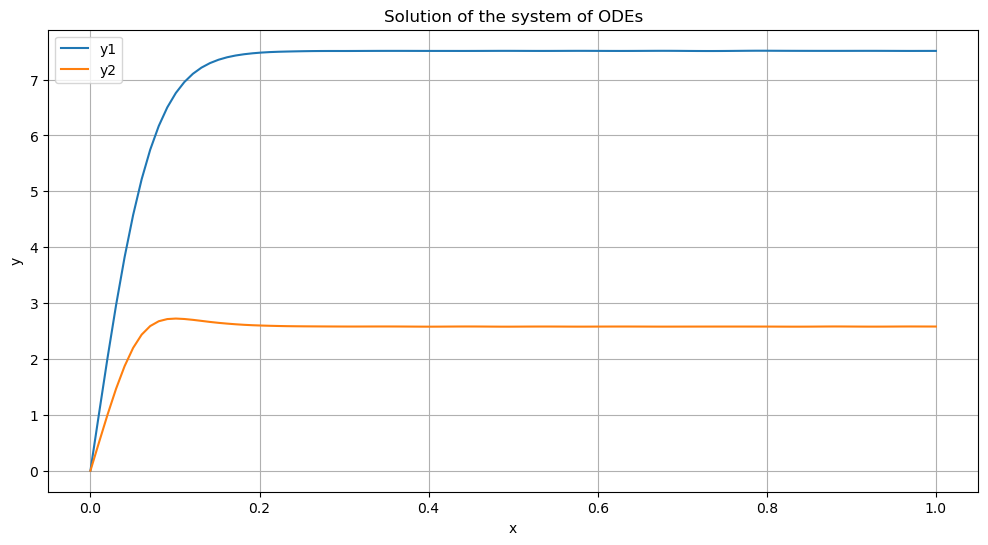

Steady-state value of y1: 7.513025562035492
Steady-state value of y2: 2.5803304189328085


In [1]:
# Import necessary libraries
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the system of ODEs
# y is a vector that contains y1 and y2
# t is the independent variable (in your case, x)
def system_of_odes(t, y):
    y1, y2 = y
    dy1dt = (500 - 10*y1**2 + 25*y2) / 5
    dy2dt = 50 - y1*y2**2
    return [dy1dt, dy2dt] 

# Define the interval of the independent variable (x)
t_span = [0, 1]

# Define the initial conditions
y_init = [0, 0]

# Solve the system of ODEs
sol = solve_ivp(system_of_odes, t_span, y_init, dense_output=True)

# Create an array of points where the solution will be evaluated
t = np.linspace(t_span[0], t_span[1], 100)

# Evaluate the solution at the points in t
y = sol.sol(t)

# Plot y1 and y2 vs x
plt.figure(figsize=(12, 6))
plt.plot(t, y[0], label='y1')
plt.plot(t, y[1], label='y2')
plt.legend(loc='best')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.title('Solution of the system of ODEs')
plt.show()

# Print the steady-state values of the functions
print(f'Steady-state value of y1: {y[0][-1]}')
print(f'Steady-state value of y2: {y[1][-1]}')


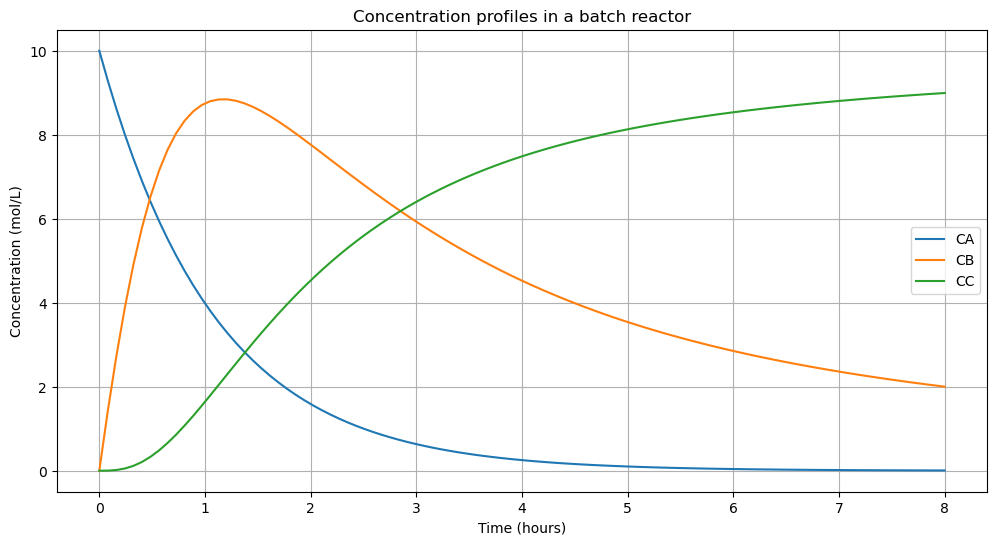

Time at which B reaches a maximum: 1.2121212121212122 hours
Maximum value of B: 8.841555291322862 mol/L


In [1]:
# Import necessary libraries
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the system of ODEs
# y is a vector that contains concentrations of A, B and C
# t is the independent variable (in your case, time)
def system_of_odes(t, y):
    CA, CB, CC = y
    k1 = 0.92  # rate constant for reaction A -> 2B
    k2 = 0.08  # rate constant for reaction 2B -> C

    # Define the ODEs
    dCAdt = -k1 * CA
    dCBdt = 2*k1 * CA - k2 * CB**2
    dCCdt = 0.5 * k2 * CB**2

    return [dCAdt, dCBdt, dCCdt]

# Define the interval of the independent variable (time in hours)
t_span = [0, 8]

# Define the initial conditions (concentrations in mol/L)
y_init = [10, 0, 0]

# Solve the system of ODEs
sol = solve_ivp(system_of_odes, t_span, y_init, dense_output=True)

# Create an array of points where the solution will be evaluated
t = np.linspace(t_span[0], t_span[1], 100)

# Evaluate the solution at the points in t
y = sol.sol(t)

# Plot the concentration profiles
plt.figure(figsize=(12, 6))
plt.plot(t, y[0], label='CA')
plt.plot(t, y[1], label='CB')
plt.plot(t, y[2], label='CC')
plt.legend(loc='best')
plt.xlabel('Time (hours)')
plt.ylabel('Concentration (mol/L)')
plt.grid(True)
plt.title('Concentration profiles in a batch reactor')
plt.show()

# Print the time at which B reaches a maximum and the maximum value
idx_max_CB = np.argmax(y[1])
t_max_CB = t[idx_max_CB]
max_CB = y[1][idx_max_CB]
print(f'Time at which B reaches a maximum: {t_max_CB} hours')
print(f'Maximum value of B: {max_CB} mol/L')
